In [1]:
from pathlib import Path
from src.db import get_connection
import sqlite3

import numpy as np
import pandas as pd

import torch

print("cuda available" if torch.cuda.is_available() else "cuda unavailable")
print("gpu ready" if torch.cuda.device_count() else "only cpu")


DATABASE_PATH = Path.home() / "HDD/Datasets/annas_archive_spotify_2025_07/spotify_clean_playlists.sqlite3"

cuda available
gpu ready


In [2]:
conn  = get_connection(DATABASE_PATH)
print("Connected to database")

Connected to database


In [3]:
def fetch_topn_playlist_tracks(conn, n):
    """Fetch all valid (playlist_rowid, track_rowid) pairs for the top N playlists
    by followers. DISTINCT ensures each track appears at most once per playlist.
    """
    query = """
        SELECT DISTINCT pt.playlist_rowid, pt.track_rowid
        FROM playlist_tracks pt
        WHERE pt.playlist_rowid IN (
            SELECT rowid 
            FROM playlists 
            ORDER BY followers_total 
            DESC LIMIT ?
        )
          AND pt.is_episode = 0
          AND pt.is_local = 0
          AND pt.track_rowid IS NOT NULL
    """
    return pd.read_sql(query, conn, params=[n])

N = 65536
_playlist_tracks = fetch_topn_playlist_tracks(conn, N)
_playlist_tracks

,playlist_rowid,track_rowid
0,3,1
1,3,4
2,3,8
3,3,9
4,3,10
...,...,...
9172521,9882401,45162248
9172522,9882401,45162240
9172523,9882401,149605019
9172524,9882401,45162245


In [4]:
def filter_kcore(pt: pd.DataFrame, k: int, min_playlist_len: int=2) -> pd.DataFrame:
    """
    Iteratively remove tracks appearing in fewer than k playlists and playlists
    with fewer than min_playlist_len tracks, until the result is stable.

    A playlist with only one remaining track produces no center-context pairs
    and is useless for skip-gram training, hence min_playlist_len=2 by default.
    """
    while True:
        n_before = len(pt)

        track_counts = pt["track_rowid"].value_counts()
        pt = pt[pt["track_rowid"].map(track_counts) >= k]

        playlist_counts = pt["playlist_rowid"].value_counts()
        pt = pt[pt["playlist_rowid"].map(playlist_counts) >= min_playlist_len]

        if len(pt) == n_before:
            break
    return pt.reset_index(drop=True)


playlist_tracks = filter_kcore(_playlist_tracks, k=3)
print(f"Interactions     : {len(playlist_tracks):,}")
print(f"Unique tracks    : {playlist_tracks['track_rowid'].nunique():,}")
print(f"Playlists        : {playlist_tracks['playlist_rowid'].nunique():,}")
print(f"Min playlist len : {playlist_tracks["playlist_rowid"].value_counts().min()}")
print(f"Min track it.    : {playlist_tracks["track_rowid"].value_counts().min()}")

Interactions     : 5,754,249
Unique tracks    : 642,015
Playlists        : 63,245
Min playlist len : 2
Min track it.    : 3


In [5]:
def build_vocab(pt: pd.DataFrame) -> pd.DataFrame:
    """Build a track_rowid → track_id mapping from the filtered interaction table.

    Assigns a contiguous integer index to each unique track_rowid. The resulting
    DataFrame is indexed by track_rowid for fast join-based lookups.
    """
    unique_tracks = pt["track_rowid"].unique()
    return pd.DataFrame({
        "track_rowid": unique_tracks,
        "track_id": np.arange(len(unique_tracks)), 
    }).set_index("track_rowid")

vocab = build_vocab(playlist_tracks)
vocab

,track_id
track_rowid,
1,0
4,1
8,2
9,3
10,4
...,...
46268887,642010
162492031,642011
213790299,642012


In [6]:
def map_vocab(pt: pd.DataFrame, vocab: pd.DataFrame) -> pd.DataFrame:
    """Replace track_rowid with the contiguous track_id from the vocab."""
    return pt.join(vocab, on="track_rowid").drop(columns=["track_rowid"])

playlist_tracks = map_vocab(playlist_tracks, vocab)
playlist_tracks

,playlist_rowid,track_id
0,3,0
1,3,1
2,3,2
3,3,3
4,3,4
...,...,...
5754244,9882401,588827
5754245,9882401,588828
5754246,9882401,588829
5754247,9882401,539868


In [7]:
def build_weights(pt: pd.DataFrame) -> torch.Tensor:
    """Build a normalised negative-sampling weight tensor aligned to track_id order.

    Weights are proportional to freq^0.75 (word2vec unigram smoothing): frequent
    tracks are sampled more often as negatives, but the exponent dampens the
    dominance of the very top tracks.

    The returned tensor has shape (vocab_size,) where position i is the sampling
    weight for track_id=i, ready for torch.multinomial.
    """
    freq = pt["track_id"].value_counts()
    weights = torch.tensor((freq ** 0.75).sort_index().to_numpy(), dtype=torch.float32)
    return weights / weights.sum()

weights = build_weights(playlist_tracks)
weights

tensor([1.7432e-05, 1.6332e-06, 1.3974e-05,  ..., 7.8266e-07, 7.8266e-07,
        7.8266e-07])

In [8]:
def flatten(pt: pd.DataFrame) -> dict[int, list[int]]:
    """Group interactions into a playlist → [track_ids] dictionary."""
    return pt.groupby("playlist_rowid")["track_id"].apply(list).to_dict()

# Model

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class Word2Vec(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int):
        super().__init__()
        self.embeddings_in = nn.Embedding(
            num_embeddings=vocab_size, embedding_dim=embed_dim, sparse=True
        )
        self.embeddings_out = nn.Embedding(
            num_embeddings=vocab_size, embedding_dim=embed_dim, sparse=True
        )
        nn.init.uniform_(self.embeddings_in.weight, -0.5 / embed_dim, 0.5 / embed_dim)
        nn.init.uniform_(self.embeddings_out.weight, -0.5 / embed_dim, 0.5 / embed_dim)

    def forward(
        self, center: torch.Tensor, context: torch.Tensor, negatives: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Returns:
            pos_score: (batch,) dot product between center and context embeddings
            neg_score: (batch, K) dot products between center and each negative embedding
        """
        ecenter = self.embeddings_in(center)
        econtext = self.embeddings_out(context)
        enegative = self.embeddings_out(negatives)

        pos_score = (ecenter * econtext).sum(dim=1)
        neg_score = torch.bmm(enegative, ecenter.unsqueeze(2)).squeeze(2)

        return pos_score, neg_score

    @property
    def track_embeddings(self) -> torch.Tensor:
        return self.embeddings_in.weight.detach()

# Loss

In [10]:
def skipgram_loss(
    pos_score: torch.Tensor, neg_score: torch.Tensor
) -> torch.Tensor:
    """Negative-sampling loss for skip-gram Word2Vec."""
    pos_loss = F.logsigmoid(pos_score)
    neg_loss = F.logsigmoid(-neg_score).sum(dim=1)
    return -(pos_loss + neg_loss).mean()

# Dataset

In [11]:
def playlist_pairs(playlist: list[int], W: int) -> tuple[torch.Tensor, torch.Tensor]:
    t = torch.tensor(playlist, dtype=torch.long)
    W = min(2 * W, len(playlist) - 1)
    offsets = [k for k in range(-W // 2, W // 2 + 1) if k]
    centers = t.repeat(len(offsets))
    contexts = torch.cat([torch.roll(t, -k) for k in offsets])
    return torch.stack((centers, contexts))



def pairs(playlist, W):
    c, x = playlist_pairs(playlist, W)
    return list(zip(c.tolist(), x.tolist()))


assert pairs([1,2,3], 1) == [(1,3),(2,1),(3,2),(1,2),(2,3),(3,1)]
assert pairs([1,2,3,4], 1) == [(1,4),(2,1),(3,2),(4,3),(1,2),(2,3),(3,4),(4,1)]
assert pairs([1,2,3,4,5], 2) == [(1,4),(2,5),(3,1),(4,2),(5,3),(1,5),(2,1),(3,2),(4,3),(5,4),(1,2),(2,3),(3,4),(4,5),(5,1),(1,3),(2,4),(3,5),(4,1),(5,2)]
assert pairs([1,2], 5) == [(1, 2), (2, 1)]
assert pairs([1,2,3,4], 100) == pairs([1,2,3,4], 2)

In [12]:
np.random.seed(0)

playlist_unique = playlist_tracks["playlist_rowid"].unique()
np.random.shuffle(playlist_unique)
playlist_train = playlist_unique[:int(0.9 * len(playlist_unique))]
train_mask = playlist_tracks["playlist_rowid"].isin(playlist_train)
train_df = playlist_tracks[train_mask].reset_index(drop=True)
valid_df = playlist_tracks[~train_mask].reset_index(drop=True)
print(f"train amounts to {100 * len(train_df) / len(playlist_tracks):.1f} % of the dataset")

train amounts to 90.1 % of the dataset


In [13]:
from typing import Callable

def get_nsampler(weights_gpu: torch.Tensor, K: int) -> Callable:
    return lambda n: torch.multinomial(weights_gpu, n * K, replacement=True).view(-1, K)


def precompute_pairs(playlists: pd.DataFrame, W: int) -> tuple[torch.Tensor, torch.Tensor]:
    return torch.cat([playlist_pairs(p, W) for p in flatten(playlists).values()], 1)


W, K = 5, 5
train = precompute_pairs(train_df, W).pin_memory()
valid = precompute_pairs(valid_df, W).pin_memory()

# Training

In [14]:
import time
from torch.optim import SparseAdam
from torch.optim.lr_scheduler import ReduceLROnPlateau

EMBED_DIM = 128
NEPOCHS = 20
LR = 1e-3
BATCH_SIZE = 128_000
SEED = 0
device = torch.device("cuda")

weights_gpu = weights.to(device)
neg_sample = get_nsampler(weights_gpu, K)
model = Word2Vec(vocab_size=len(vocab), embed_dim=EMBED_DIM)
model = model.to(device)
optimizer = SparseAdam(model.parameters(), lr=LR)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

history = {"train": [], "valid": [], "lr": []}
best_valid_loss = float("inf")
best_state = None
best_epoch = -1

for epoch in range(NEPOCHS):
    t0 = time.perf_counter()
    torch.manual_seed(SEED + epoch)
    perm = torch.randperm(train.shape[1])
    centers, contexts = train
    centers_s, contexts_s = centers[perm], contexts[perm]

    model.train()
    nt, tloss_epoch = 0, 0.
    for nt, offset in enumerate(range(0, len(centers_s), BATCH_SIZE)):
        c = centers_s[offset:offset+BATCH_SIZE].to(device, non_blocking=True)
        x = contexts_s[offset:offset+BATCH_SIZE].to(device, non_blocking=True)
        n = neg_sample(len(c))

        optimizer.zero_grad()
        loss = skipgram_loss(*model(c, x, n))
        loss.backward()
        optimizer.step()
        tloss_epoch += loss.item()

    t1 = time.perf_counter()
    perm = torch.randperm(valid.shape[1])
    centers, contexts = valid
    centers_s, contexts_s = centers[perm], contexts[perm]

    model.eval()
    nv, vloss_epoch = 0, 0.
    with torch.no_grad():
        for nv, offset in enumerate(range(0, len(centers_s), BATCH_SIZE)):
            c = centers_s[offset:offset+BATCH_SIZE].to(device, non_blocking=True)
            x = contexts_s[offset:offset+BATCH_SIZE].to(device, non_blocking=True)
            n = neg_sample(len(c))
            vloss_epoch += skipgram_loss(*model(c, x, n)).item()

    t2 = time.perf_counter()

    train_loss = tloss_epoch / (nt + 1)
    valid_loss = vloss_epoch / (nv + 1)
    lr = optimizer.param_groups[0]["lr"]
    history["train"].append(train_loss)
    history["valid"].append(valid_loss)
    history["lr"].append(lr)

    is_best = valid_loss < best_valid_loss
    if is_best:
        best_valid_loss = valid_loss
        best_epoch = epoch + 1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    scheduler.step(valid_loss)

    w = len(str(NEPOCHS))
    print(
        f"epoch {epoch+1:{w}}/{NEPOCHS}"
        f"  │  train {train_loss:.4f}"
        f"  valid {valid_loss:.4f}"
        f"  │  lr {lr:.2e}"
        f"  │  {t2-t0:.0f}s  (train {t1-t0:.0f}s  valid {t2-t1:.0f}s)"
        + ("  *" if is_best else "")
    )

model.load_state_dict(best_state)
print(f"\nRestored best model from epoch {best_epoch}  (valid {best_valid_loss:.4f})")

epoch  1/20  │  train 3.4714  valid 2.5846  │  lr 1.00e-03  │  26s  (train 25s  valid 0s)  *
epoch  2/20  │  train 2.1759  valid 2.0647  │  lr 1.00e-03  │  27s  (train 26s  valid 0s)  *
epoch  3/20  │  train 1.7457  valid 1.7544  │  lr 1.00e-03  │  26s  (train 25s  valid 0s)  *
epoch  4/20  │  train 1.4342  valid 1.5190  │  lr 1.00e-03  │  25s  (train 25s  valid 0s)  *
epoch  5/20  │  train 1.2073  valid 1.3464  │  lr 1.00e-03  │  25s  (train 25s  valid 0s)  *
epoch  6/20  │  train 1.0414  valid 1.2200  │  lr 1.00e-03  │  26s  (train 25s  valid 0s)  *
epoch  7/20  │  train 0.9187  valid 1.1286  │  lr 1.00e-03  │  26s  (train 26s  valid 0s)  *
epoch  8/20  │  train 0.8283  valid 1.0653  │  lr 1.00e-03  │  26s  (train 26s  valid 0s)  *
epoch  9/20  │  train 0.7625  valid 1.0225  │  lr 1.00e-03  │  26s  (train 26s  valid 0s)  *
epoch 10/20  │  train 0.7139  valid 0.9936  │  lr 1.00e-03  │  25s  (train 25s  valid 0s)  *
epoch 11/20  │  train 0.6771  valid 0.9749  │  lr 1.00e-03  │  25s  (t

### Recap

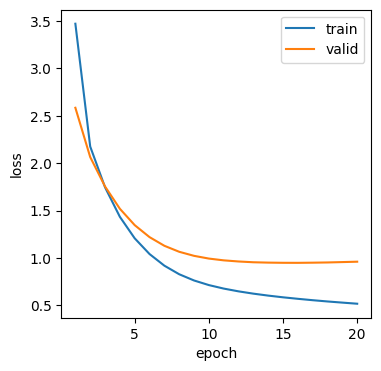

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 4))
epochs = range(1, len(history["train"]) + 1)
ax.plot(epochs, history["train"], label="train")
ax.plot(epochs, history["valid"], label="valid")
ax.set_xlabel("epoch"); ax.set_ylabel("loss"); ax.legend()
plt.show()

# Qualitative checks

In [16]:
# Load track lookup, keep only columns we need, inner-join with vocab
lookup = pd.read_parquet(
    "../data/playlist/track_lookup.parquet",
    columns=["track_rowid", "track_name", "artist_name", "track_popularity"],
)
lookup = lookup.merge(vocab, on="track_rowid", how="inner")
print(f"{len(lookup):,} tracks in lookup (should match vocab size {len(vocab):,})")
lookup.head()

642,015 tracks in lookup (should match vocab size 642,015)


,track_rowid,track_name,artist_name,track_popularity,track_id
0,1,The Giver,Chappell Roan,89,0
1,4,Crash,NOTD,56,1
2,5,I Just Missed A Call,NOTD,51,29
3,7,WIFI,NOTD,55,38895
4,8,SMOKE THE PAIN AWAY,Calvin Harris,75,2


In [17]:
# L2-normalise embeddings once — cosine sim becomes a simple matmul
emb = model.track_embeddings.to(device)
emb_norm = emb / emb.norm(dim=1, keepdim=True)


def find_neighbours(query: str, k: int = 10) -> pd.DataFrame:
    """Find top-k nearest neighbours by cosine similarity.

    `query` is matched case-insensitively against track_name. If multiple tracks
    match, the most popular one is used.
    """
    matches = lookup[lookup["track_name"].str.contains(query, case=False, na=False)]
    if matches.empty:
        print(f"No tracks matching '{query}'")
        return pd.DataFrame()

    row = matches.sort_values("track_popularity", ascending=False).iloc[0]
    tid = row["track_id"]
    print(f"Query: {row['track_name']} — {row['artist_name']}  (pop {row['track_popularity']})")

    sims = (emb_norm[tid] @ emb_norm.T).cpu().numpy()
    top_idx = np.argsort(sims)[::-1][1 : k + 1]  # skip self

    result = lookup[lookup["track_id"].isin(top_idx)].copy()
    result["similarity"] = sims[result["track_id"].values]
    result = result.sort_values("similarity", ascending=False)
    return result[["track_name", "artist_name", "track_popularity", "similarity"]]

In [22]:
queries = [
    "Holland, 1945",
    "Interzone",
    "About A Girl",
    "Battery",
    "Xtal",
    "Altibzz",
    "N.Y. State of Mind",
    "Mathematics",
    "Nuthin' But A 'G' Thang",
    "Figaro",
    "Bela Lugosi's Dead",
    "Just Like Heaven",
    "Once in a Lifetime",
    "Be Quiet and Drive",
]

for q in queries:
    display(find_neighbours(q))
    print()

Query: Holland, 1945 — Neutral Milk Hotel  (pop 59)


,track_name,artist_name,track_popularity,similarity
17401,Reckoner,Radiohead,69,0.950821
275659,Cut Your Hair,Pavement,56,0.945340
238710,Culture,Car Seat Headrest,36,0.943462
333257,Stereo,Pavement,45,0.943034
333256,Spit on a Stranger,Pavement,53,0.942889
390423,Permanent Daylight,Radiohead,52,0.941533
393119,Wave Of Mutilation - UK Surf,Pixies,52,0.938611
333258,Shady Lane,Pavement,47,0.938348
366210,Sail To The Moon,Radiohead,59,0.937946
275661,Gold Soundz,Pavement,51,0.937321



Query: Interzone - 2007 Remaster — Joy Division  (pop 47)


,track_name,artist_name,track_popularity,similarity
459463,Decades - 2007 Remaster,Joy Division,0,0.986946
372578,Israel,Siouxsie and the Banshees,0,0.985929
564332,No Words,Clan of Xymox,0,0.985731
558831,Moonchild,Fields Of The Nephilim,0,0.985605
413201,Promised Land,Skeletal Family,0,0.985308
459453,Pain,Boy Harsher,0,0.984222
565000,One Hundred Years,The Cure,33,0.984203
354435,Painted Black,Mephisto Walz,42,0.984071
558828,Dead And Buried,Alien Sex Fiend,0,0.982632
563698,Empty Room,Ash Code,15,0.982596



Query: About A Girl — Nirvana  (pop 78)


...

,track_name,artist_name,track_popularity,similarity
287796,Love Will Tear Us Apart - 2020 Remaster,Joy Division,70,0.914126
44005,Inbetween Days,The Cure,67,0.893751
272293,If You Leave - Remastered 2019,Orchestral Manoeuvres In The Dark,61,0.888086
363706,A Forest,The Cure,68,0.884789
7661,Friday I'm In Love,The Cure,77,0.878176
4590,How Soon Is Now? - 2011 Remaster,The Smiths,75,0.875758
285664,"Head Over Heels - Dave Bascombe 7"" N.Mix",Tears For Fears,72,0.875588
76316,Lovesong - Remastered,The Cure,70,0.873725
19136,Disorder - 2007 Remaster,Joy Division,67,0.872074
19068,Ceremony,New Order,56,0.870629



Query: Once in a Lifetime - 2005 Remaster — Talking Heads  (pop 68)


,track_name,artist_name,track_popularity,similarity
24037,"Call Me - Theme From ""American Gigolo"" / Remas...",Blondie,43,0.917345
360681,And She Was,Talking Heads,62,0.915566
237675,Echo Beach,Martha and the Muffins,59,0.914554
25596,China Girl - 2018 Remaster,David Bowie,61,0.908671
363548,Whip It,DEVO,52,0.906528
420097,Heartbreak Beat,The Psychedelic Furs,32,0.905601
415877,Head Over Heels,The Go-Go's,51,0.904733
286446,Sound and Vision - 2017 Remaster,David Bowie,62,0.903966
333725,Message To My Girl,Split Enz,42,0.903394
368347,I Ran (So Far Away) - Single Edit,A Flock Of Seagulls,63,0.902537



Query: Be Quiet and Drive (Far Away) — Deftones  (pop 80)


,track_name,artist_name,track_popularity,similarity
35177,Rosemary,Deftones,76,0.926546
18443,My Own Summer (Shove It),Deftones,79,0.924055
275921,Beware,Deftones,70,0.911702
18445,Mascara,Deftones,76,0.911702
275920,Hole in the Earth,Deftones,68,0.906966
23473,Digital Bath,Deftones,73,0.904810
23478,Knife Prty,Deftones,65,0.904319
24133,Aneurysm,Nirvana,67,0.901319
40590,7 Words,Deftones,69,0.901015
23481,Change (In the House of Flies),Deftones,81,0.900734


## Curated genre UMAP

In [23]:
# Parse genre_artists.txt → {genre: [artist_name]}
genre_artists = {}
current_genre = None
with open("genre_artists.txt") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        if line.startswith("#"):
            current_genre = line[1:].strip()
            genre_artists[current_genre] = []
        else:
            genre_artists[current_genre].append(line)

for g, artists in genre_artists.items():
    print(f"{g}: {len(artists)} artists")

new-wave: 14 artists
post-punk: 14 artists
70s-punk: 13 artists
grunge: 13 artists
thrash-metal: 13 artists
black-metal: 13 artists
dark-wave: 13 artists
90s-west-coast-hip-hop: 13 artists
90s-east-coast-hip-hop: 13 artists
conscious-hip-hop: 13 artists
IDM: 13 artists


In [24]:
# Join curated artists with lookup to get their tracks + track_ids
rows = []
for genre, artists in genre_artists.items():
    for artist in artists:
        mask = lookup["artist_name"].str.lower() == artist.lower()
        matched = lookup[mask]
        for _, row in matched.iterrows():
            rows.append({
                "genre": genre,
                "artist_name": row["artist_name"],
                "track_name": row["track_name"],
                "track_id": row["track_id"],
            })

genre_df = pd.DataFrame(rows)
print(f"{len(genre_df):,} tracks matched across {genre_df['genre'].nunique()} genres")
print(f"{genre_df['artist_name'].str.lower().nunique()} unique artists matched")
print()
print(genre_df["genre"].value_counts().to_string())

5,690 tracks matched across 11 genres
137 unique artists matched

genre
90s-east-coast-hip-hop    991
90s-west-coast-hip-hop    931
new-wave                  808
thrash-metal              660
grunge                    604
conscious-hip-hop         517
post-punk                 417
70s-punk                  271
IDM                       252
dark-wave                 170
black-metal                69


In [25]:
import umap

# Extract embeddings for the curated tracks
track_ids = genre_df["track_id"].values
genre_emb = emb_norm[track_ids].cpu().numpy()

reducer = umap.UMAP(n_components=2, metric="cosine")
coords = reducer.fit_transform(genre_emb)
genre_df["umap_x"] = coords[:, 0]
genre_df["umap_y"] = coords[:, 1]
print(f"UMAP done — {len(coords)} points")

UMAP done — 5690 points


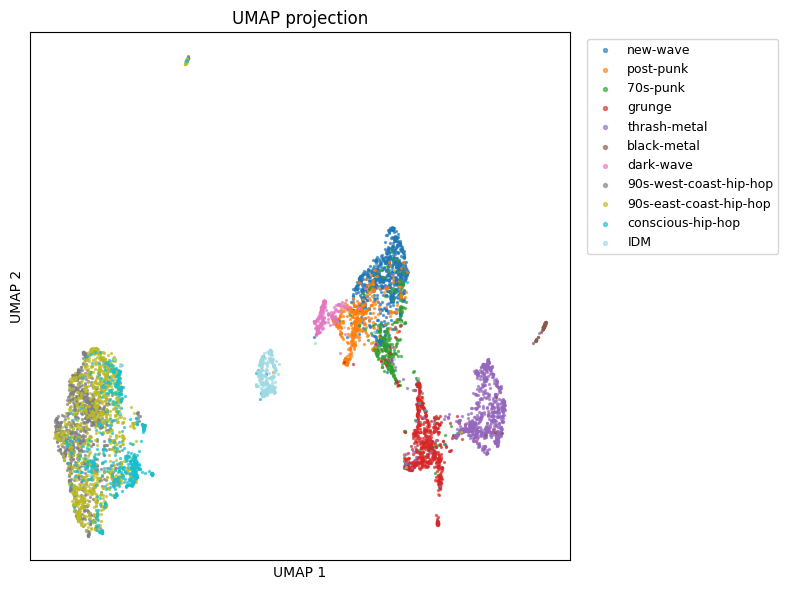

In [26]:
import matplotlib

fig, ax = plt.subplots(figsize=(8, 6))

genres = genre_df["genre"].unique()
cmap = plt.colormaps["tab20"].resampled(len(genres))

for i, genre in enumerate(genres):
    subset = genre_df[genre_df["genre"] == genre]
    ax.scatter(
        subset["umap_x"], subset["umap_y"],
        c=[cmap(i)], label=genre, s=2, alpha=0.6,
    )

ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9, markerscale=2)
ax.set_title("UMAP projection")
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()